In [1]:
import hea
from hea import col

### Replication of Figure 4 from Ran et al. (2020)

In [2]:
data = (
    hea.read_csv("https://raw.githubusercontent.com/berenslab/rgc_dendrites/refs/heads/master/data/processed/overlap.csv")
        .rename(
            roi_dist="dendritic_distance_between_rois",
            angle="cbpt_angle_between_rois_deg",
            overlap="overlap_index",
        )
        .select("cell_id", "type", "roi_dist", "overlap", "angle")
        .mutate(cell_id=col("cell_id").cast(hea.Int64))
        .mutate(hea.factor(
            col("type").cast(hea.Int64),
            labels={"0": "alpha transient", "1": "sustained", "2": "mini alpha", "3": "f-mini"},
        ))
)

offsets = (
    data.group_by("type")
        .summarize(step=col("cell_id").max() + 1)
        .mutate(offset=hea.lag(hea.cumsum(col("step")), default=0))
        .select("type", "offset")
)

data = (
    data.left_join(offsets, by="type")
        .mutate(cell_id=col("cell_id") + col("offset"))
        .drop("offset")
        .filter(col("roi_dist") < 300)
        .mutate(hea.factor("cell_id"))
)

In [3]:
data

cell_id,type,roi_dist,overlap,angle
enum,enum,f64,f64,f64
"""0""","""alpha transient""",11.655505,0.867386,132.988429
"""0""","""alpha transient""",3.325,0.97784,18.434949
"""0""","""alpha transient""",23.235176,0.918401,90.0
"""0""","""alpha transient""",30.507996,0.918557,65.149677
"""0""","""alpha transient""",9.281426,0.96853,81.869898
…,…,…,…,…
"""30""","""f-mini""",9.72642,0.911793,121.010898
"""30""","""f-mini""",3.274087,0.93578,7.958054
"""30""","""f-mini""",5.193016,0.999633,0.0


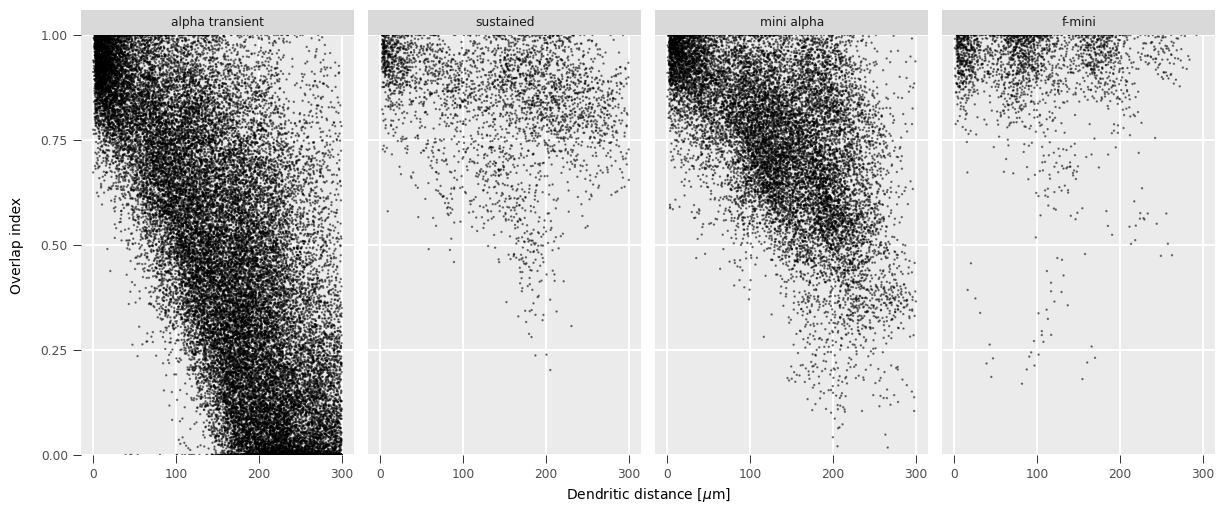

In [4]:
(
    data
        .ggplot(x="roi_dist", y="overlap")
        .geom_point(alpha=0.5, shape=16, size=.5)
        .facet_wrap("~type", ncol=4)
        .ylim((0,1))
        .labs(x=r"Dendritic distance [$\mu$m]", y="Overlap index")
).show(figsize=(12, 5))

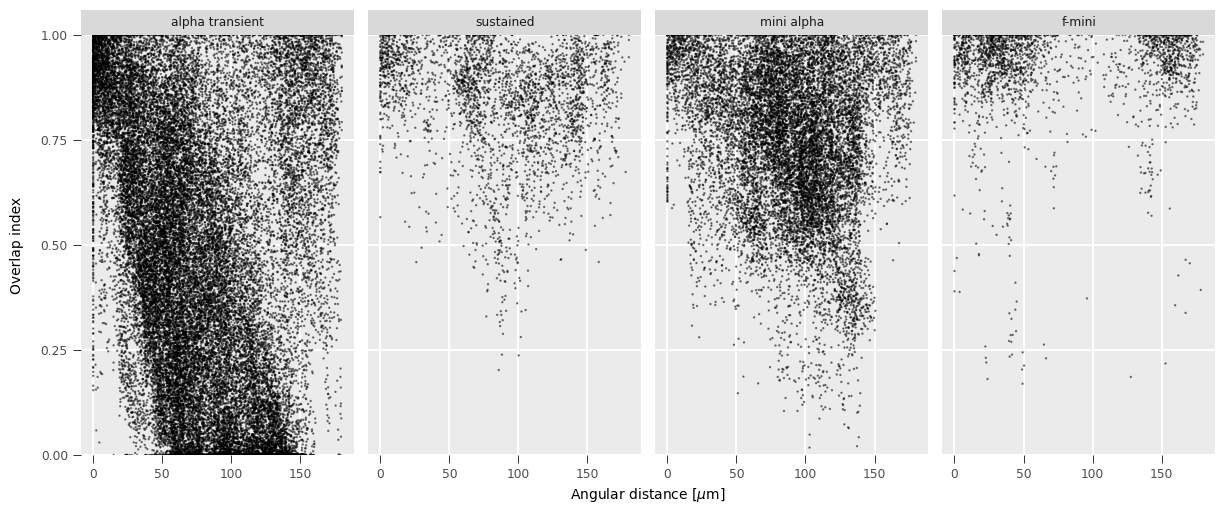

In [5]:
(
    data
        .ggplot(x="angle", y="overlap")
        .geom_point(alpha=0.5, shape=16, size=.5)
        .facet_wrap("~type", ncol=4)
        .ylim((0,1))
        .labs(x=r"Angular distance [$\mu$m]", y="Overlap index")
).show(figsize=(12, 5))

In [6]:
m1 = hea.gam('overlap ~ type + te(roi_dist, angle, by=type, k=10)', data = data)
m1.summary()


Family: gaussian
Link function: identity

Formula: overlap ~ type + te(roi_dist, angle, by=type, k=10)

Parametric coefficients:
                 Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)     0.4651984   0.0008099  574.386   < 2e-16  ***
typesustained   0.3708086   0.0045604   81.310   < 2e-16  ***
typemini alpha  0.2563440   0.0053631   47.797   < 2e-16  ***
typef-mini      0.4499675   0.0725452    6.203  5.59e-10  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                          edf  Ref.df         F  p-value
te(roi_dist,angle):typealpha transient  91.47   96.73  1311.928   <2e-16  ***
te(roi_dist,angle):typesustained        60.06   72.20     8.236   <2e-16  ***
te(roi_dist,angle):typemini alpha       98.35   98.87    77.941   <2e-16  ***
te(roi_dist,angle):typef-mini           52.24   58.72     3.819   <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq

In [7]:
m2 = hea.gam('overlap ~ type + te(roi_dist, angle, by=type, k=10) + s(cell_id, bs="re")', data = data)
m2.summary()


Family: gaussian
Link function: identity

Formula: overlap ~ type + te(roi_dist, angle, by=type, k=10) + s(cell_id, bs="re")

Parametric coefficients:
                Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)      0.52816     0.02893   18.255   < 2e-16  ***
typesustained    0.28101     0.06602    4.256  2.08e-05  ***
typemini alpha   0.21896     0.06062    3.612  0.000304  ***
typef-mini       0.28018     0.06091    4.600  4.24e-06  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                           edf  Ref.df         F  p-value
te(roi_dist,angle):typealpha transient  82.264  91.759  1334.633  < 2e-16  ***
te(roi_dist,angle):typesustained        53.584  66.354     9.207  < 2e-16  ***
te(roi_dist,angle):typemini alpha       98.421  98.906    82.433  < 2e-16  ***
te(roi_dist,angle):typef-mini            4.210   5.116     3.609  0.00266  **
s(cell_id)                              26.670  27

In [8]:
hea.AIC(m1, m2)

            df        AIC
m1  324.309517  -52105.46
m2  294.113827  -58040.02


In [9]:
hea.anova(m1, m2, test="F")

Analysis of Deviance Table

m1: overlap ~ type + te(roi_dist, angle, by=type, k=10)
m2: overlap ~ type + te(roi_dist, angle, by=type, k=10) + s(cell_id, bs="re")

     Resid. Df  Resid. Dev       Df   Deviance          F  Pr(>F)
m2  53900.8862   1075.5921
m1  53846.2944   1198.7302  54.5918  -123.1381  -101.3992     1.0
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


<Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical Quantiles', ylabel='Std. deviance resid.'>

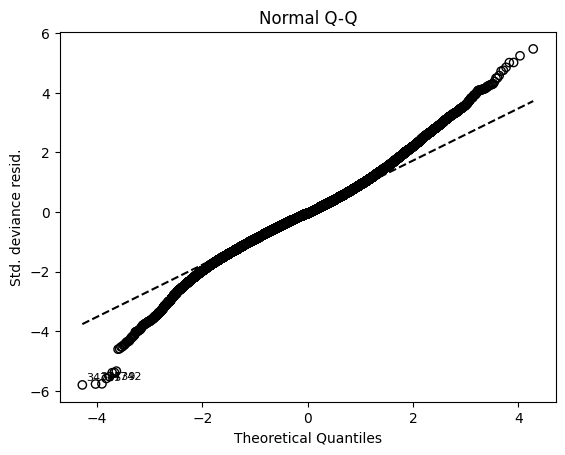

In [10]:
m2.plot_qq()

In [11]:
# r1 = hea.gam('overlap ~ type + te(roi_dist, angle, by=type, k=10) + s(cell_id, bs="re")', data = data)
# r1.summary()

In [12]:
# r2 = hea.gam('overlap ~ type + s(roi_dist, by=type, k=10) + s(roi_dist, by=type, k=10) + s(cell_id, bs="re")', data = data)
# r2.summary()

In [13]:
# hea.anova(r2,r1, test="F")

In [14]:
from hea.family import scat
m3 = hea.bam('overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")', 
          data=data, 
          family=scat(min_df=5), 
          discrete=True)
m3.summary()


Family: Scaled t(5,0.109)
Link function: identity

Formula: overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")

Parametric coefficients:
                Estimate  Std. Error  z value  Pr(>|z|)
(Intercept)      0.53489     0.02197   24.342   < 2e-16  ***
typesustained    0.28511     0.05018    5.682  1.33e-08  ***
typemini alpha   0.21361     0.04710    4.536  5.75e-06  ***
typef-mini       0.28791     0.04736    6.080  1.20e-09  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                           edf  Ref.df     Chi.sq  p-value
te(roi_dist,angle):typealpha transient  239.03  291.21  175596.66  < 2e-16  ***
te(roi_dist,angle):typef-mini            16.38   22.54      45.00  0.00398  **
te(roi_dist,angle):typemini alpha       199.42  244.49   11358.19  < 2e-16  ***
te(roi_dist,angle):typesustained         69.24   95.49     857.74  < 2e-16  ***
s(cell_id)                          

<Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical Quantiles', ylabel='Std. deviance resid.'>

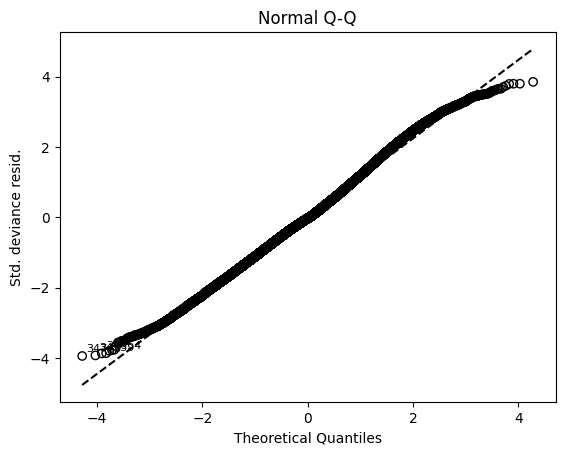

In [15]:
m3.plot_qq()

In [16]:
hea.AIC(m3)

            df        AIC
m3  568.619578  -61818.91


In [17]:
m3.check()

Method: REML   Optimizer: outer newton
Smoothing parameters fixed by user — no outer optimization.
Model rank = 1631 / 1631

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                                            k'     edf  k-index  p-value
te(roi_dist,angle):typealpha transient  399.00  239.03     1.00     0.55
te(roi_dist,angle):typef-mini           399.00   16.38     1.00     0.63
te(roi_dist,angle):typemini alpha       399.00  199.42     1.00     0.57
te(roi_dist,angle):typesustained        399.00   69.24     1.00     0.64
s(cell_id)                               31.00   26.48      NaN      NaN
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


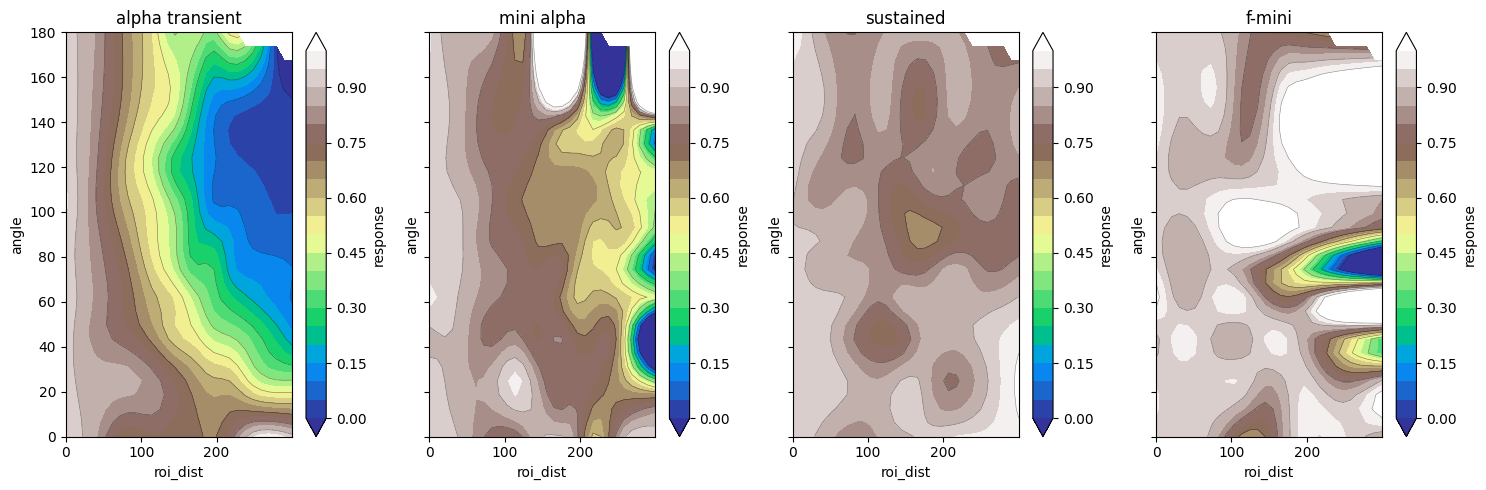

In [18]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)
for ax, lvl in zip(axes, ["alpha transient","mini alpha", "sustained", "f-mini"]):
    m1.vis(
        view=["roi_dist", "angle"],
        cond={"type": lvl},
        type="response",
        too_far=0.1,
    ).plot(
        ax=ax, aspect="auto", cmap="terrain", 
        vmin=0, vmax=1,
        contour_levels=np.linspace(0, 1, 11))
    ax.set_title(lvl)
plt.tight_layout()

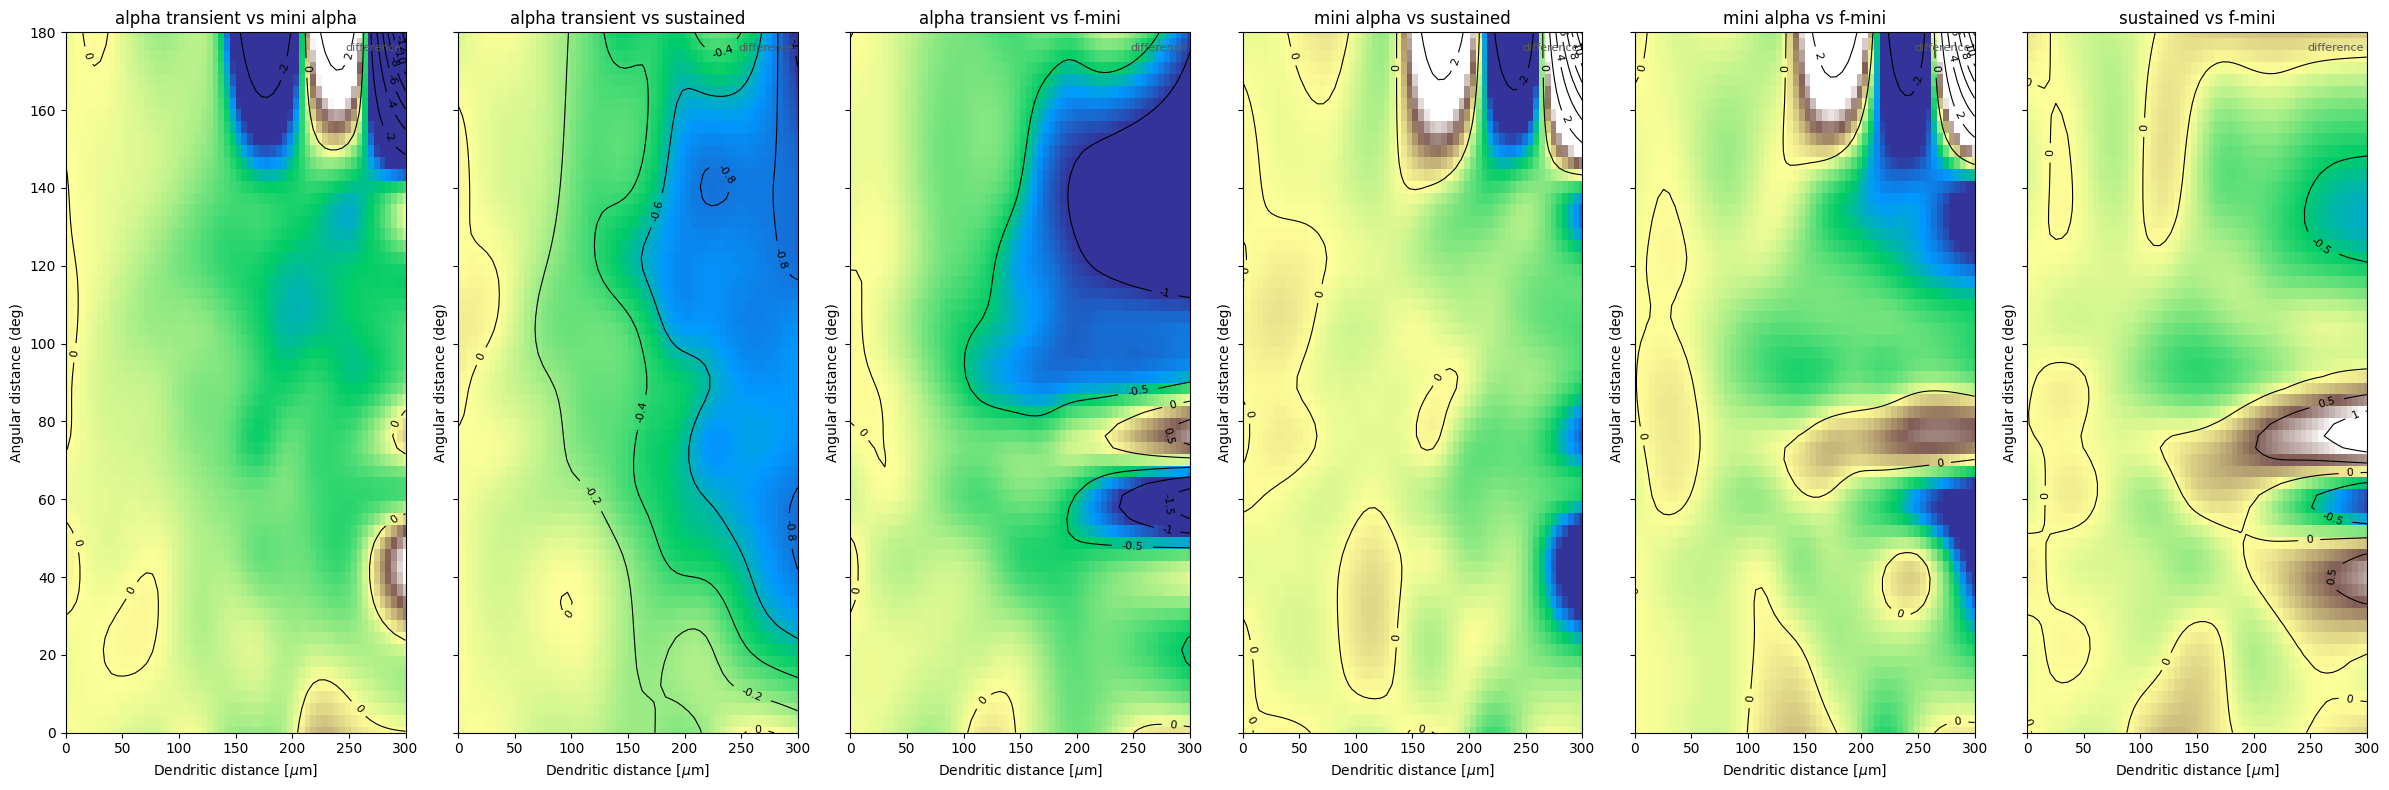

In [19]:
import matplotlib.pyplot as plt
import numpy as np

types = ["alpha transient", "mini alpha", "sustained", "f-mini"]
pairs = [(types[t], types[d])
         for t in range(len(types)) for d in range(t+1, len(types))]
# 6 pairs

fig, axes = plt.subplots(1, 6, figsize=(24, 8), sharey=True)
for ax, (a, b) in zip(axes, pairs):
    m1.plot_diff2(
        view=["roi_dist", "angle"],
        comp={"type": (a, b)},
        col_diff="white",                      # R: col.diff='white'
        rm_ranef=True,                         # R: rm.ranef=TRUE
        n_grid=60,
        zlim=(-1, 1),
        xlim=(0, 300),
        ylim=(0, 180),
        color="terrain",                            # the helper from earlier
        title=f"{a} vs {b}",
        xlab=r"Dendritic distance [$\mu$m]",
        ylab="Angular distance (deg)",
        add_color_legend=False,
        ax=ax,
    )
plt.tight_layout()
